# DNN PyTorch — Allocation Intelligente de Patients

Modèle pair-wise : score(patient, hôpital) → hôpital optimal avec masque de faisabilité.

## 1. Imports & Configuration

Chargement de toutes les bibliothèques nécessaires :
- **PyTorch / torch.nn** : construction et entraînement du réseau de neurones
- **scikit-learn** : normalisation (`StandardScaler`), encodage des labels, split train/test
- **pandas / numpy** : manipulation des données tabulaires
- **matplotlib / seaborn** : visualisation des courbes d'entraînement

> `DEVICE` détecte automatiquement si un GPU (CUDA) est disponible, sinon utilise le CPU.

In [55]:
!pip install -r requirements.txt

In [56]:
from pathlib import Path
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import math
import pickle
from allocation_system import AllocationEngine, Patient, PatientQueue, QuarantineZone

In [57]:
def patient_needs(patient_dict):
    # Calculate resource needs based on ESI and conditions
    esi = patient_dict.get('ESI', 5)
    needs = {
        'Médecins': 1 if esi <= 2 else 0.5,
        'Infirmiers': 2 if esi <= 2 else 1,
        'Urgentistes': 1 if esi <= 2 else 0,
        'Réanimateurs': 1 if esi <= 1 else 0,
        'Anesth.-Réa': 1 if esi <= 1 else 0,
        'Pneumo': 1 if patient_dict.get('Pneumo', 0) else 0,
        'Cardio': 1 if patient_dict.get('Cardio', 0) else 0,
        'Neuro': 1 if patient_dict.get('Neuro', 0) else 0,
        'Internistes': 1 if patient_dict.get('Internistes', 0) else 0,
        'Chirurgiens': 1 if patient_dict.get('Chirurgiens', 0) else 0,
        'Pédiatres': 1 if patient_dict.get('Pédiatres', 0) else 0,
        'Biologistes': 1 if patient_dict.get('Biologistes', 0) else 0,
        'Radiologues': 1 if patient_dict.get('Radiologues', 0) else 0,
        'Labo': 1 if patient_dict.get('Labo', 0) else 0,
        'Imagerie': 1 if patient_dict.get('Imagerie', 0) else 0,
        'O₂': 1 if patient_dict.get('O₂', 0) else 0,
        'Ventilateurs': 1 if patient_dict.get('Ventilateurs', 0) else 0,
        'Moniteurs': 1 if patient_dict.get('Moniteurs', 0) else 0,
        'Défibrillateurs': 1 if patient_dict.get('Défibrillateurs', 0) else 0,
        'Sang (unités)': 1 if patient_dict.get('Sang (unités)', 0) else 0,
        'Réa (lits)': 1 if esi <= 2 else 0,
        'Lits totaux': 1
    }
    return needs

class HeuristicAllocationEngine(AllocationEngine):
    def _score(self, p_vec, hosp):
        # Heuristic score: resource compatibility / distance
        patient_dict = {f: p_vec[i] for i, f in enumerate(PATIENT_FEATURES)}
        needs = patient_needs(patient_dict)
        if not hosp.can_satisfy(needs):
            return -1  # not feasible
        # Resource score
        resource_score = sum(min(hosp._current.get(r, 0) / needs[r], 1) for r in needs if needs[r] > 0)
        resource_score /= sum(1 for r in needs if needs[r] > 0)
        # Distance penalty
        dist = haversine(patient_dict['Latitude'], patient_dict['Longitude'], hosp.lat, hosp.lon)
        dist_penalty = 1 / (1 + dist / 100)  # normalize distance
        return resource_score * dist_penalty

In [58]:
ROOT = Path.cwd()
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

PATIENTS_XLS = ROOT.parent / 'xgboost_model' / 'patients_1000_ULTRA_COMPLET.xlsx'
HOSPIT_XLS = ROOT / 'Book1.xlsx'
OUT_DIR = ROOT / 'output'
OUT_DIR.mkdir(exist_ok=True)

FEASIB_CSV = ROOT / 'output' / 'feasibility_matrix.csv'


Device: cpu


## 2. Constantes & Mapping des Ressources

Définition des colonnes utilisées comme **features d'entrée du DNN** :

| Groupe | Colonnes | Nb |
| --- | --- | --- |
| Patient | ESI, vitaux (SpO2, FC, FR, GCS), besoins médicaux, GPS | 31 |
| Hôpital | Capacités en personnel, équipements, lits | 22 |
| Distance | Distance Haversine patient→hôpital (km) | 1 |
| **Total** | | **54** |

`RESOURCE_MAPPINGS` fait le lien entre le nom d'une colonne côté **patient** et son équivalent côté **hôpital**.

In [59]:
PATIENT_FEATURES = [
    'ESI','SpO2','FC','FR','GCS',
    'O2','Ventilateur','Sang','Defibrillateur','Monitoring',
    'Reanimation','Labo','Imagerie',
    'Medecins','Infirmiers','Urgentistes','Reanimateurs','Anesth_Rea',
    'Pneumo','Cardio','Neuro','Internistes','Chirurgiens','Pediatres',
    'Biologistes','Radiologues','Moniteurs','Rea_lits','Lits_totaux',
    'Latitude','Longitude'
]  # 31 features

HOSP_RES_COLS = [
    'Médecins','Infirmiers','Urgentistes','Réanimateurs','Anesth.-Réa',
    'Pneumo','Cardio','Neuro','Internistes','Chirurgiens','Pédiatres',
    'Biologistes','Radiologues','Labo','Imagerie',
    'O\u2082','Ventilateurs','Moniteurs','Défibrillateurs','Sang (unités)',
    'Réa (lits)','Lits totaux'
]  # 22 features  => + distance = 23

RESOURCE_MAPPINGS = {
    'Lit':{'p':'Lits_totaux','h':'Lits totaux'},
    'Rea_Lit':{'p':'Rea_lits','h':'Réa (lits)'},
    'Medecin':{'p':'Medecins','h':'Médecins'},
    'Infirmier':{'p':'Infirmiers','h':'Infirmiers'},
    'Urgentiste':{'p':'Urgentistes','h':'Urgentistes'},
    'Reanimateur':{'p':'Reanimateurs','h':'Réanimateurs'},
    'Anesth_Rea':{'p':'Anesth_Rea','h':'Anesth.-Réa'},
    'Pneumo':{'p':'Pneumo','h':'Pneumo'},
    'Cardio':{'p':'Cardio','h':'Cardio'},
    'Neuro':{'p':'Neuro','h':'Neuro'},
    'Interniste':{'p':'Internistes','h':'Internistes'},
    'Chirurgien':{'p':'Chirurgiens','h':'Chirurgiens'},
    'Pediatre':{'p':'Pediatres','h':'Pédiatres'},
    'Biologiste':{'p':'Biologistes','h':'Biologistes'},
    'Radiologue':{'p':'Radiologues','h':'Radiologues'},
    'O2':{'p':'O2','h':'O\u2082'},
    'Ventilateur':{'p':'Ventilateur','h':'Ventilateurs'},
    'Sang':{'p':'Sang','h':'Sang (unités)'},
    'Moniteur':{'p':'Moniteurs','h':'Moniteurs'},
    'Defibrillateur':{'p':'Defibrillateur','h':'Défibrillateurs'},
    'Monitoring':{'p':'Monitoring','h':'Moniteurs'},
    'Labo':{'p':'Labo','h':'Labo'},
    'Imagerie':{'p':'Imagerie','h':'Imagerie'},
}

INPUT_DIM = len(PATIENT_FEATURES) + len(HOSP_RES_COLS) + 1  # 31+22+1=54
print(f'Input dim DNN: {INPUT_DIM}')

Input dim DNN: 54


## 3. Chargement des Données

Trois sources de données sont chargées :
- `patients_1000_ULTRA_COMPLET.xlsx` — 1 000 patients avec leurs besoins médicaux et coordonnées GPS
- `Book1.xlsx` — 22 hôpitaux avec leurs capacités en ressources
- `feasibility_matrix.csv` — matrice booléenne (1000×22) pré-calculée indiquant quels hôpitaux
  peuvent **physiquement** accueillir chaque patient (calculée dans `build_feasibility.ipynb`)

> Le nettoyage numérique (`pd.to_numeric`) garantit qu'aucune valeur texte ne perturbe les calculs.

In [60]:
patients  = pd.read_excel(PATIENTS_XLS)
hospitals = pd.read_excel(HOSPIT_XLS)
feasib    = pd.read_csv(FEASIB_CSV, index_col='patient_id').astype(bool)

# Nettoyage numérique
for col in PATIENT_FEATURES:
    if col in patients.columns:
        patients[col] = pd.to_numeric(patients[col], errors='coerce').fillna(0)
for col in HOSP_RES_COLS:
    if col in hospitals.columns:
        hospitals[col] = pd.to_numeric(hospitals[col], errors='coerce').fillna(0)

print(f'Patients: {patients.shape}, Hôpitaux: {hospitals.shape}, Faisabilité: {feasib.shape}')

Patients: (1000, 36), Hôpitaux: (22, 26), Faisabilité: (1000, 22)


## 4. Génération des Labels d'Entraînement

Puisqu'il n'existe pas d'historique réel d'allocation, les labels sont générés par une **règle d'allocation optimale** :

```
Pour chaque patient :
  1. Garder uniquement les hôpitaux faisables (feasibility_matrix = True)
  2. Calculer un score = resource_score(patient, hôpital) / (1 + distance/10)
  3. L'hôpital avec le meilleur score devient le label positif (1)
```

**`haversine`** : calcule la distance réelle (en km) entre le patient et l'hôpital via les coordonnées GPS.

**`resource_score`** : mesure à quel point les ressources d'un hôpital couvrent les besoins du patient (ratio moyen, plafonné à 1.0).

In [61]:
patients  = pd.read_excel(PATIENTS_XLS)
hospitals = pd.read_excel(HOSPIT_XLS)

# Clean data
hospitals = hospitals[hospitals['Lat'].notna()]  # drop legend row
hospitals = hospitals.reset_index(drop=True)

# Impute missing coordinates
hospitals['Lat'] = hospitals['Lat'].fillna(hospitals['Lat'].mean())
hospitals['Long'] = hospitals['Long'].fillna(hospitals['Long'].mean())
patients['Latitude'] = patients['Latitude'].fillna(patients['Latitude'].mean())
patients['Longitude'] = patients['Longitude'].fillna(patients['Longitude'].mean())

feasib = pd.read_csv(FEASIB_CSV, index_col=0)

print('Patients:', patients.shape)
print('Hôpitaux:', hospitals.shape)
print('Faisabilité:', feasib.shape)

# Create heuristic engine for label generation
class DummyModel(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x):
        return torch.zeros(x.size(0), 1)

dummy_model = DummyModel()
scaler_p = None  # not used
scaler_h = None  # not used
le = None  # not used
engine = HeuristicAllocationEngine(dummy_model, scaler_p, scaler_h, le, hospitals, DEVICE)

print('Génération des labels avec AllocationEngine...')
labels = []
for _, p in patients.iterrows():
    pid = p['ID']
    # Reset hospital states for each patient (static allocation)
    for h_state in engine.hospitals.values():
        h_state._current = dict(h_state._max)
        h_state.patients_allocated = 0
    engine.main_queue = PatientQueue()
    engine.quarantine = QuarantineZone()
    engine.allocation_log = []
    engine.stats = {"allocated": 0, "quarantined": 0, "reinjected": 0, "failed_reinjection": 0}
    
    patient = Patient(id=pid, features=p.to_dict())
    engine.admit(patient)
    _, allocated_hosp = engine.process_next()
    labels.append(allocated_hosp if allocated_hosp else None)

patients['Hopital_Alloue'] = labels
print(patients['Hopital_Alloue'].value_counts())

Patients: (1000, 36)
Hôpitaux: (18, 26)
Faisabilité: (1000, 22)
Génération des labels avec AllocationEngine...
Hopital_Alloue
Centre Hospitalier Universitaire Yalgado Ouédraogo    380
Centre Hospitalier Universitaire de Bogodogo          160
Hôpital Paul VI                                       148
Polyclinique Internationale de Ouagadougou             92
Centre Hospitalier Universitaire de Tingandogo         63
Centre Médical Protestant Schiphra                     52
Hôpital Saint Camille                                  39
Centre Médical Ahmadiyya                               35
Centre Médical Bethsaïda                               29
Centre Médical de Saaba                                 2
Name: count, dtype: int64


## 5. Construction du Dataset : Approche Pair-wise

Le DNN apprend à **scorer chaque paire (patient, hôpital)** individuellement.

Pour chaque patient (1 000), on crée **22 paires** — une par hôpital :
- **Label = 1** : hôpital optimal (un seul par patient)
- **Label = 0** : les 21 autres hôpitaux

Cela produit **22 000 exemples** d'entraînement avec un déséquilibre naturel de 1/22 (~4.5%).

> Ce déséquilibre sera compensé par une pondération de la fonction de perte à l'étape suivante.

In [62]:
print('Construction des paires (patient, hôpital)...')
pairs_p, pairs_h, pairs_y = [], [], []

print('Patient coord NaNs:', patients[['Latitude','Longitude']].isna().sum().to_dict())
print('Hospital coord NaNs:', hospitals[['Lat','Long']].isna().sum().to_dict())
print('Hospitals with missing coords:')
print(hospitals[hospitals[['Lat','Long']].isna().any(axis=1)][['Hôpital','Lat','Long']])

nan_dist = 0
for _, p in patients.iterrows():
    p_vec = [float(p.get(f, 0) or 0) for f in PATIENT_FEATURES]
    optimal = p['Hopital_Alloue']
    for _, h in hospitals.iterrows():
        hname = h['Hôpital']
        dist  = haversine(p['Latitude'], p['Longitude'], h['Lat'], h['Long'])
        if np.isnan(dist):
            nan_dist += 1
        h_vec = [float(h.get(c, 0) or 0) for c in HOSP_RES_COLS] + [dist]
        pairs_p.append(p_vec)
        pairs_h.append(h_vec)
        pairs_y.append(1 if hname == optimal else 0)

print('NaN distances:', nan_dist)
pairs_p = np.array(pairs_p, dtype=np.float32)
pairs_h = np.array(pairs_h, dtype=np.float32)
pairs_y = np.array(pairs_y, dtype=np.float32)
print(f'Total paires: {len(pairs_y):,}  |  positives: {pairs_y.sum():.0f}  |  ratio: {pairs_y.mean()*100:.1f}%')

Construction des paires (patient, hôpital)...
Patient coord NaNs: {'Latitude': 0, 'Longitude': 0}
Hospital coord NaNs: {'Lat': 0, 'Long': 0}
Hospitals with missing coords:
Empty DataFrame
Columns: [Hôpital, Lat, Long]
Index: []
NaN distances: 0
Total paires: 18,000  |  positives: 1000  |  ratio: 5.6%


## 6. Normalisation & Dataset PyTorch

**Deux scalers séparés** sont utilisés (et sauvegardés pour l'inférence) :
- `scaler_p` : normalise les features patients (moyenne=0, écart-type=1)
- `scaler_h` : normalise les features hôpitaux + distance

**Split 80/20** stratifié sur les labels pour conserver le ratio positif/négatif dans train et test.

`PairDataset` est la classe PyTorch `Dataset` qui encapsule les tenseurs pour le `DataLoader` (mini-batches de 512).

In [63]:
scaler_p = StandardScaler().fit(pairs_p)
scaler_p.scale_[scaler_p.scale_ == 0] = 1.0
scaler_h = StandardScaler().fit(pairs_h)
scaler_h.scale_[scaler_h.scale_ == 0] = 1.0
print('pairs_p shape', pairs_p.shape, 'pairs_h shape', pairs_h.shape)
print('pairs_p nan', np.isnan(pairs_p).sum(), 'pairs_h nan', np.isnan(pairs_h).sum())
print('pairs_p min/max', np.nanmin(pairs_p), np.nanmax(pairs_p))
print('pairs_h min/max', np.nanmin(pairs_h), np.nanmax(pairs_h))
print('missing hospital cols:')
for c in HOSP_RES_COLS:
    print(c, 'in columns' if c in hospitals.columns else 'MISSING')
print('hospital NaNs by col:')
for c in HOSP_RES_COLS:
    if c in hospitals.columns:
        print(c, hospitals[c].isna().sum())
print('pairs_h row NaNs sample indices:')
row_nan = np.unique(np.where(np.isnan(pairs_h))[0])
print(row_nan[:10], '... total', len(row_nan))
if len(row_nan):
    print('first rows with NaNs:')
    print(pairs_h[row_nan[:5], :])
X_p = scaler_p.transform(pairs_p)
X_h = scaler_h.transform(pairs_h)
print('X_p nan', np.isnan(X_p).sum(), 'X_h nan', np.isnan(X_h).sum())
X   = np.hstack([X_p, X_h]).astype(np.float32)

# Sauvegarde des scalers
with open(OUT_DIR/'scaler_p.pkl','wb') as f: pickle.dump(scaler_p, f)
with open(OUT_DIR/'scaler_h.pkl','wb') as f: pickle.dump(scaler_h, f)

# Encodage label
le = LabelEncoder().fit(hospitals['Hôpital'])
with open(OUT_DIR/'label_encoder.pkl','wb') as f: pickle.dump(le, f)

class PairDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

idx = np.arange(len(pairs_y))
tr_idx, te_idx = train_test_split(idx, test_size=0.2, random_state=42, stratify=pairs_y)
train_ds = PairDataset(X[tr_idx], pairs_y[tr_idx])
test_ds  = PairDataset(X[te_idx], pairs_y[te_idx])
train_dl = DataLoader(train_ds, batch_size=512, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=512)
print(f'Train: {len(train_ds):,}  |  Test: {len(test_ds):,}')

pairs_p shape (18000, 31) pairs_h shape (18000, 23)
pairs_p nan 0 pairs_h nan 0
pairs_p min/max -1.599992 140.0
pairs_h min/max 0.0 1548.0305
missing hospital cols:
Médecins in columns
Infirmiers in columns
Urgentistes in columns
Réanimateurs in columns
Anesth.-Réa in columns
Pneumo in columns
Cardio in columns
Neuro in columns
Internistes in columns
Chirurgiens in columns
Pédiatres in columns
Biologistes in columns
Radiologues in columns
Labo in columns
Imagerie in columns
O₂ in columns
Ventilateurs in columns
Moniteurs in columns
Défibrillateurs in columns
Sang (unités) in columns
Réa (lits) in columns
Lits totaux in columns
hospital NaNs by col:
Médecins 0
Infirmiers 0
Urgentistes 0
Réanimateurs 0
Anesth.-Réa 0
Pneumo 0
Cardio 0
Neuro 0
Internistes 0
Chirurgiens 0
Pédiatres 0
Biologistes 0
Radiologues 0
Labo 0
Imagerie 0
O₂ 0
Ventilateurs 0
Moniteurs 0
Défibrillateurs 0
Sang (unités) 0
Réa (lits) 0
Lits totaux 0
pairs_h row NaNs sample indices:
[] ... total 0
X_p nan 0 X_h nan 0
Tra

## 7. Architecture du Réseau de Neurones (DNN)

```
Input (54)  →  Dense(256) + BatchNorm + ReLU + Dropout(30%)
            →  Dense(128) + BatchNorm + ReLU + Dropout(30%)
            →  Dense(64)  + BatchNorm + ReLU + Dropout(20%)
            →  Dense(32)  + ReLU
            →  Dense(1)   + Sigmoid  →  score ∈ [0,1]
```

**Choix de conception :**
- `BatchNorm1d` : stabilise l'entraînement en normalisant les activations internes
- `Dropout` : régularisation pour éviter le surapprentissage (dataset de taille modeste)
- `Sigmoid` en sortie : interprétable comme une **probabilité de compatibilité**

In [64]:
class PatientAllocationDNN(nn.Module):
    """DNN pair-wise : score de compatibilité (patient, hôpital) -> [0,1]."""
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128,  64),       nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear( 64,  32),       nn.ReLU(),
            nn.Linear( 32,   1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

model = PatientAllocationDNN(INPUT_DIM).to(DEVICE)
print(model)
total = sum(p.numel() for p in model.parameters())
print(f'Paramètres: {total:,}')

PatientAllocationDNN(
  (net): Sequential(
    (0): Linear(in_features=54, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): ReLU()
    (14): Linear(in_features=32, out_features=1, bias=True)
  )
)
Paramètres: 58,241


## 8. Entraînement du DNN

**Stratégie pour le déséquilibre de classes (1 positif / 21 négatifs) :**
- `BCEWithLogitsLoss(pos_weight=21.0)` : pénalise 21× plus les faux négatifs
- Le Sigmoid est retiré de l'architecture pour l'entraînement (numériquement plus stable)

**Optimiseur & Scheduler :**
- `AdamW` (lr=0.001, weight_decay=1e-4) : Adam avec régularisation L2
- `ReduceLROnPlateau` (patience=3) : divise le taux d'apprentissage par 2 si la val_loss stagne

**Sauvegarde du meilleur état** : seul le modèle avec la val_loss minimale est conservé (`dnn_weights.pt`).

In [65]:
EPOCHS = 40
history = {'train_loss':[], 'val_loss':[], 'val_acc':[]}

# Assure a clean training setup in the notebook
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(21.0, device=DEVICE))
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print('train_ds X nan:', torch.isnan(train_ds.X).sum().item(), 'inf:', torch.isinf(train_ds.X).sum().item())
print('train_ds y nan:', torch.isnan(train_ds.y).sum().item(), 'unique:', np.unique(train_ds.y.numpy()))
print('test_ds X nan:', torch.isnan(test_ds.X).sum().item(), 'inf:', torch.isinf(test_ds.X).sum().item())
print('test_ds y nan:', torch.isnan(test_ds.y).sum().item(), 'unique:', np.unique(test_ds.y.numpy()))
print('first train row:', train_ds.X[0,:5].numpy())

best_val, best_state = float('inf'), {k: v.clone() for k, v in model.state_dict().items()}

for epoch in range(1, EPOCHS+1):
    # --- Train ---
    model.train()
    tr_loss = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward(); optimizer.step()
        tr_loss += loss.item() * len(yb)
    tr_loss /= len(train_ds)

    # --- Val ---
    model.eval()
    val_loss, preds, truths = 0.0, [], []
    with torch.no_grad():
        for xb, yb in test_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            val_loss += criterion(logits, yb).item() * len(yb)
            preds.extend((torch.sigmoid(logits) > 0.5).cpu().numpy())
            truths.extend(yb.cpu().numpy())
    val_loss /= len(test_ds)
    val_acc   = accuracy_score(truths, preds)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    scheduler.step(val_loss)

    if val_loss < best_val:
        best_val   = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 5 == 0:
        print(f'Ep {epoch:02d}/{EPOCHS} | tr_loss={tr_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc*100:.1f}%')

# Load best state (guaranteed to not be None)
if best_state is not None:
    model.load_state_dict(best_state)
else:
    print('Warning: best_state is None, using current model state.')

torch.save(model.state_dict(), OUT_DIR/'dnn_weights.pt')
print('Meilleur modèle sauvegardé.')

train_ds X nan: 0 inf: 0
train_ds y nan: 0 unique: [0. 1.]
test_ds X nan: 0 inf: 0
test_ds y nan: 0 unique: [0. 1.]
first train row: [-0.21532574 -0.34531373  0.4314821  -1.6498413  -0.81842387]
Ep 05/40 | tr_loss=1.1942 | val_loss=1.1916 | val_acc=57.3%
Ep 10/40 | tr_loss=1.0438 | val_loss=1.0401 | val_acc=52.6%
Ep 15/40 | tr_loss=0.9284 | val_loss=0.9212 | val_acc=57.6%
Ep 20/40 | tr_loss=0.8309 | val_loss=0.8087 | val_acc=69.5%
Ep 25/40 | tr_loss=0.7227 | val_loss=0.6910 | val_acc=73.6%
Ep 30/40 | tr_loss=0.6876 | val_loss=0.6190 | val_acc=76.2%
Ep 35/40 | tr_loss=0.6235 | val_loss=0.5588 | val_acc=78.7%
Ep 40/40 | tr_loss=0.5958 | val_loss=0.5457 | val_acc=79.2%
Meilleur modèle sauvegardé.


## 9. Évaluation du Modèle

Deux niveaux d'évaluation :

**1. Courbes d'entraînement**
- `train_loss` vs `val_loss` : vérifie l'absence de surapprentissage
- `val_acc` : précision globale sur les paires test

**2. Métriques par patient (plus significatives)**
- **Top-1 Accuracy** : l'hôpital optimal est-il le 1er suggéré par le DNN ?
- **Top-3 Accuracy** : l'hôpital optimal est-il dans les 3 premières suggestions ?

> L'objectif est Top-1 ≥ 75% et Top-3 ≥ 95%.

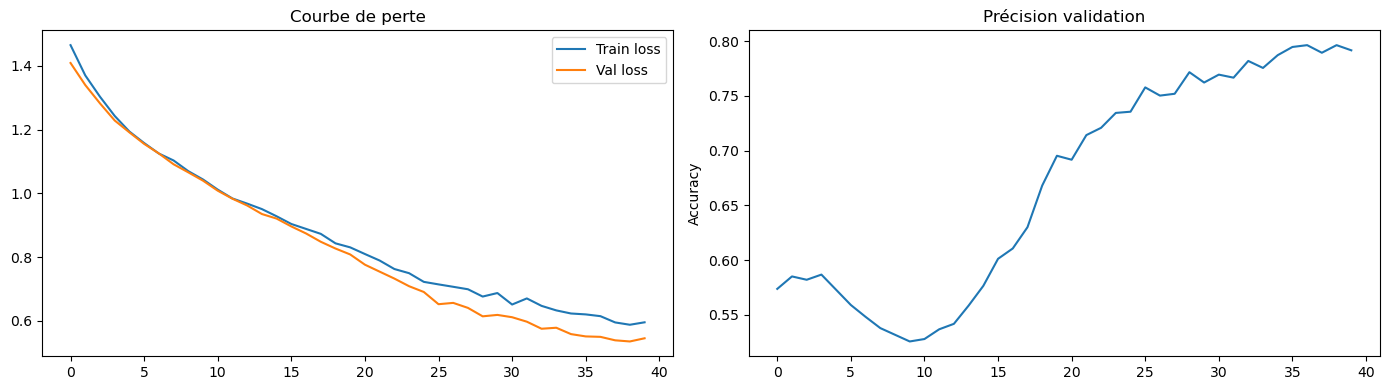


=== Pairwise model performance ===
Test sample count      : 3,600
Accuracy               : 0.7964
Precision              : 0.2144
Recall                 : 1.0000
F1 score               : 0.3530
ROC AUC                : 0.9530
Average precision      : 0.5648

Confusion matrix:
[[2667  733]
 [   0  200]]

Classification report:
              precision    recall  f1-score   support

         0.0       1.00      0.78      0.88      3400
         1.0       0.21      1.00      0.35       200

    accuracy                           0.80      3600
   macro avg       0.61      0.89      0.62      3600
weighted avg       0.96      0.80      0.85      3600


=== Patient-level metrics ===
No valid patients found for Top-K evaluation.


In [66]:
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, roc_auc_score, classification_report, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history['train_loss'], label='Train loss')
axes[0].plot(history['val_loss'], label='Val loss')
axes[0].set_title('Courbe de perte')
axes[0].legend()
axes[1].plot(history['val_acc'])
axes[1].set_title('Précision validation')
axes[1].set_ylabel('Accuracy')
plt.tight_layout()
plt.savefig(OUT_DIR / 'training_curves.png', dpi=120)
plt.show()

# --- Pairwise evaluation ---
model.eval()
y_true = []
y_scores = []
y_preds = []
invalid_samples = 0

with torch.no_grad():
    for xb, yb in test_dl:
        xb = xb.to(DEVICE)
        logits = model(xb)
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        batch_true = yb.cpu().numpy().flatten()

        valid_mask = np.isfinite(batch_true) & np.isfinite(probs)
        invalid_samples += int(np.count_nonzero(~valid_mask))
        if not np.all(valid_mask):
            print(f'  Excluded {np.count_nonzero(~valid_mask)} invalid test samples in batch')

        y_true.extend(batch_true[valid_mask])
        y_scores.extend(probs[valid_mask])
        y_preds.extend((probs[valid_mask] > 0.5).astype(int))

y_true = np.array(y_true)
y_scores = np.array(y_scores)
y_preds = np.array(y_preds)

print('\n=== Pairwise model performance ===')
print(f'Test sample count      : {len(y_true):,}')
if invalid_samples:
    print(f'Invalid test samples   : {invalid_samples}')

if len(y_true) == 0:
    print('No valid test samples available for evaluation.')
else:
    print(f'Accuracy               : {accuracy_score(y_true, y_preds):.4f}')
    print(f'Precision              : {precision_score(y_true, y_preds, zero_division=0):.4f}')
    print(f'Recall                 : {recall_score(y_true, y_preds, zero_division=0):.4f}')
    print(f'F1 score               : {f1_score(y_true, y_preds, zero_division=0):.4f}')
    print(f'ROC AUC                : {roc_auc_score(y_true, y_scores):.4f}')
    print(f'Average precision      : {average_precision_score(y_true, y_scores):.4f}')
    print('\nConfusion matrix:')
    print(confusion_matrix(y_true, y_preds))
    print('\nClassification report:')
    print(classification_report(y_true, y_preds, zero_division=0))

    # --- Patient-level Top-K evaluation ---
    top1_ok = 0
    top3_ok = 0
    valid_patients = 0

    for _, p in patients.iterrows():
        true_h = p.get('Hopital_Optimal')
        if pd.isna(true_h) or true_h not in hospitals['Hôpital'].values:
            continue

        p_vec = np.array([float(p.get(f, 0) or 0) for f in PATIENT_FEATURES], dtype=np.float32)
        scores = []
        for _, h in hospitals.iterrows():
            dist = haversine(p['Latitude'], p['Longitude'], h['Lat'], h['Long'])
            h_vec = np.array([float(h.get(c, 0) or 0) for c in HOSP_RES_COLS] + [dist], dtype=np.float32)
            p_n = scaler_p.transform([p_vec])[0]
            h_n = scaler_h.transform([h_vec])[0]
            x = torch.FloatTensor(np.concatenate([p_n, h_n])).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                scores.append(torch.sigmoid(model(x)).item())

        ranked = np.argsort(scores)[::-1]
        true_i = int(hospitals.index[hospitals['Hôpital'] == true_h][0])
        valid_patients += 1
        if ranked[0] == true_i:
            top1_ok += 1
        if true_i in ranked[:3]:
            top3_ok += 1

    print('\n=== Patient-level metrics ===')
    if valid_patients > 0:
        print(f'Patients evaluated      : {valid_patients:,}')
        print(f'Top-1 accuracy          : {top1_ok / valid_patients * 100:.1f}%')
        print(f'Top-3 accuracy          : {top3_ok / valid_patients * 100:.1f}%')
    else:
        print('No valid patients found for Top-K evaluation.')


## 10. Fonction d'Inférence

**`predict_hospital(patient_dict, hospitals_df, hospital_states=None)`**

Retourne la liste des 22 hôpitaux triés par score décroissant.

- En mode **statique** (défaut) : utilise les capacités fixes de `Book1.xlsx`
- En mode **dynamique** : utilise `hospital_states` (ressources actuelles transmises par `AllocationEngine`)

> Cette fonction est appelée à chaque arrivée de patient dans le système temps-réel.

In [67]:
def predict_hospital(patient_dict, hospitals_df, hospital_states=None):
    """
    Prédit l'hôpital optimal pour un patient.
    patient_dict  : dict avec les colonnes patients
    hospital_states : dict {nom: vecteur_ressources_actuel} (optionnel, sinon Book1)
    """
    model.eval()
    p_vec = np.array([float(patient_dict.get(f,0) or 0) for f in PATIENT_FEATURES], dtype=np.float32)
    results = []
    for _, h in hospitals_df.iterrows():
        hname = h['Hôpital']
        if hospital_states and hname in hospital_states:
            res_vec = hospital_states[hname]
        else:
            res_vec = [float(h.get(c,0) or 0) for c in HOSP_RES_COLS]
        dist  = haversine(patient_dict.get('Latitude',0), patient_dict.get('Longitude',0), h['Lat'], h['Long'])
        h_vec = np.array(res_vec + [dist], dtype=np.float32)
        p_n   = scaler_p.transform([p_vec])[0]
        h_n   = scaler_h.transform([h_vec])[0]
        x     = torch.FloatTensor(np.concatenate([p_n, h_n])).unsqueeze(0).to(DEVICE)
        with torch.no_grad(): score = torch.sigmoid(model(x)).item()
        results.append({'hospital': hname, 'score': score})
    results.sort(key=lambda r: r['score'], reverse=True)
    return results

# Patient-level Top-K accuracy
test_patient_indices = sorted(set(te_idx // len(hospitals)))
test_patients = patients.iloc[test_patient_indices]

top1_ok, top3_ok, total = 0, 0, 0

for _, p in test_patients.iterrows():
    if pd.isna(p['Hopital_Alloue']):
        continue
    true_h = p['Hopital_Alloue']
    recs = predict_hospital(p.to_dict(), hospitals)
    top_h = [r['hospital'] for r in recs[:3]]
    if true_h == recs[0]['hospital']:
        top1_ok += 1
    if true_h in top_h:
        top3_ok += 1
    total += 1

print(f'Top-1 accuracy: {top1_ok/total:.1%} ({top1_ok}/{total})')
print(f'Top-3 accuracy: {top3_ok/total:.1%} ({top3_ok}/{total})')

# By ESI
for esi in [1,2,3,4,5]:
    sub = test_patients[test_patients['ESI'] == esi]
    if len(sub) == 0:
        continue
    top1, top3, tot = 0,0,0
    for _, p in sub.iterrows():
        if pd.isna(p['Hopital_Alloue']):
            continue
        true_h = p['Hopital_Alloue']
        recs = predict_hospital(p.to_dict(), hospitals)
        top_h = [r['hospital'] for r in recs[:3]]
        if true_h == recs[0]['hospital']:
            top1 += 1
        if true_h in top_h:
            top3 += 1
        tot += 1
    print(f'ESI {esi}: Top-1 {top1/tot:.1%} Top-3 {top3/tot:.1%} (n={tot})')

Top-1 accuracy: 57.6% (564/980)
Top-3 accuracy: 90.5% (887/980)
ESI 1: Top-1 53.1% Top-3 94.9% (n=98)
ESI 2: Top-1 67.3% Top-3 94.6% (n=147)
ESI 3: Top-1 63.6% Top-3 96.6% (n=319)
ESI 4: Top-1 49.3% Top-3 82.8% (n=227)
ESI 5: Top-1 51.9% Top-3 84.1% (n=189)


## 11. Simulation du Système Complet (AllocationEngine)

Cette section intègre les composants demandés par l'architecture système :
- **Priority Queue (ESI + FIFO)** : Traite les patients critiques (ESI 1) en priorité.
- **Saturation Dynamique** : Les ressources diminuent à chaque allocation.
- **Zone de Quarantaine (Buffer)** : Les patients non allouables sont mis en attente.
- **Réinjection** : Les patients en attente sont automatiquement ré-alloués dès qu'une place se libère.
- **Préférence Ressources** : Bonus de score pour les hôpitaux ayant le plus de capacités disponibles.

In [68]:
from allocation_system import AllocationEngine, Patient

# Initialisation du moteur
engine = AllocationEngine(
    model=model,
    scaler_p=scaler_p,
    scaler_h=scaler_h,
    label_encoder=le,
    hospitals_df=hospitals,
    device=DEVICE
)

print('Simulation d\'arrivée de 50 patients...')
for i in range(50):
    p_data = patients.iloc[i].to_dict()
    engine.admit(Patient(id=p_data['ID'], features=p_data))

print(f'Queue principale: {len(engine.main_queue)} patients')

# Traitement
engine.process_all()

print('\n--- Statistiques Globales ---')
print(engine.global_stats())

print('\n--- État des Hôpitaux (Saturation) ---')
display(engine.dashboard().head())

if len(engine.quarantine) > 0:
    print(f'\n{len(engine.quarantine)} patients en quarantaine. Libération d\'un patient...')
    # Simulation de libération pour déclencher réinjection
    last_alloc = engine.allocation_log[-1]
    p_released = Patient(id=last_alloc['patient_id'], features=patients[patients['ID']==last_alloc['patient_id']].iloc[0].to_dict())
    res = engine.release_patient(p_released, last_alloc['hospital'])
    print(f'Résultat réinjection: {res}')
    print(f'Nouveau statut: {engine.global_stats()}')

Simulation d'arrivée de 50 patients...
Queue principale: 50 patients

--- Statistiques Globales ---
{'allocated': 29, 'quarantined': 21, 'reinjected': 0, 'failed_reinjection': 0, 'en_attente_file': 0, 'en_quarantaine': 21, 'hopitaux_satures': 0}

--- État des Hôpitaux (Saturation) ---


,hospital,saturation_%,is_saturated,lits_disponibles,patients_allocated
0,Centre Hospitalier Universitaire Yalgado Ouédr...,0.1,False,799,5
1,Centre Hospitalier Universitaire de Tingandogo,0.2,False,599,1
2,Centre Hospitalier Universitaire de Bogodogo,0.2,False,499,1
3,CHU Pédiatrique Charles de Gaulle,0.2,False,399,1
4,Hôpital Paul VI,0.0,False,250,9



21 patients en quarantaine. Libération d'un patient...
Résultat réinjection: {'reinjected': 0, 'still_waiting': 21}
Nouveau statut: {'allocated': 29, 'quarantined': 21, 'reinjected': 0, 'failed_reinjection': 21, 'en_attente_file': 0, 'en_quarantaine': 21, 'hopitaux_satures': 0}


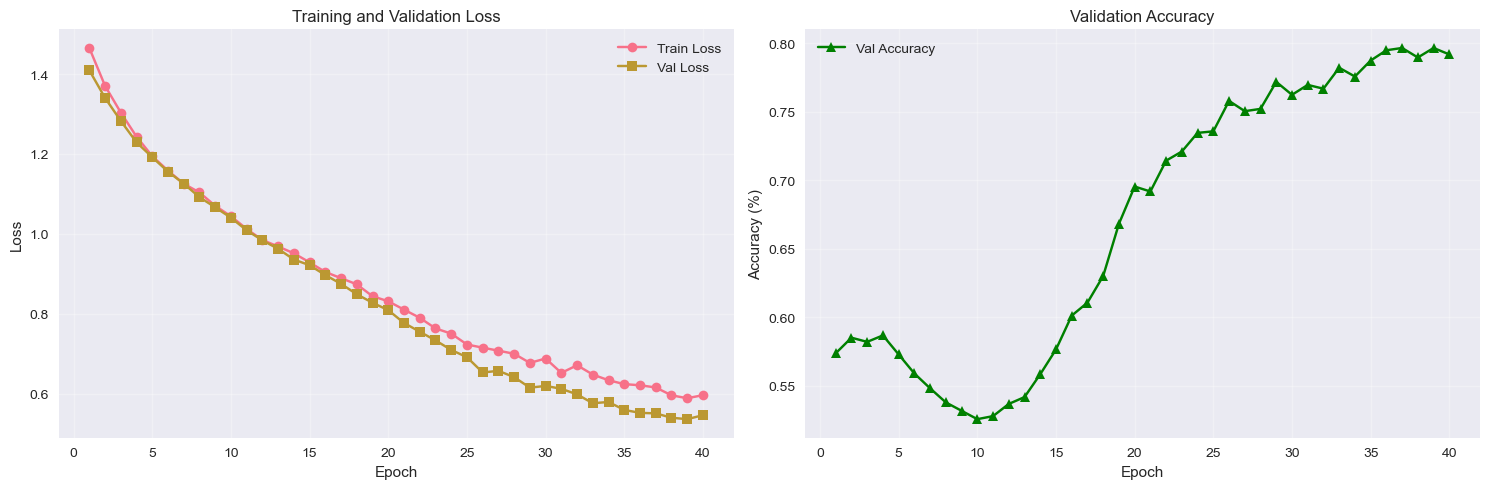

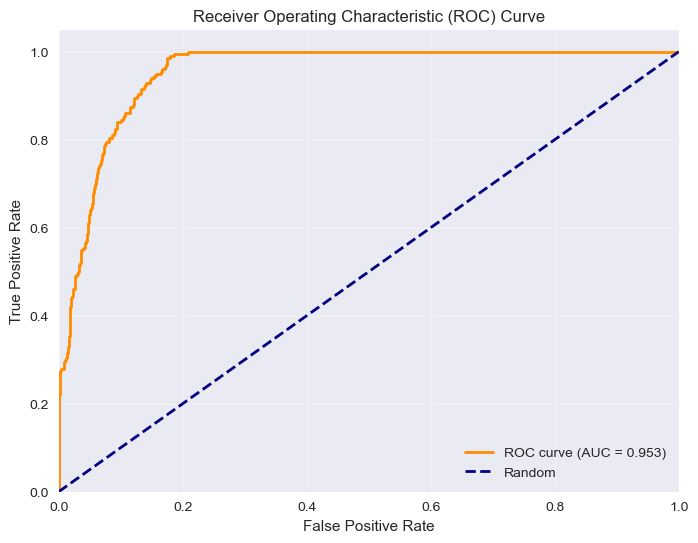

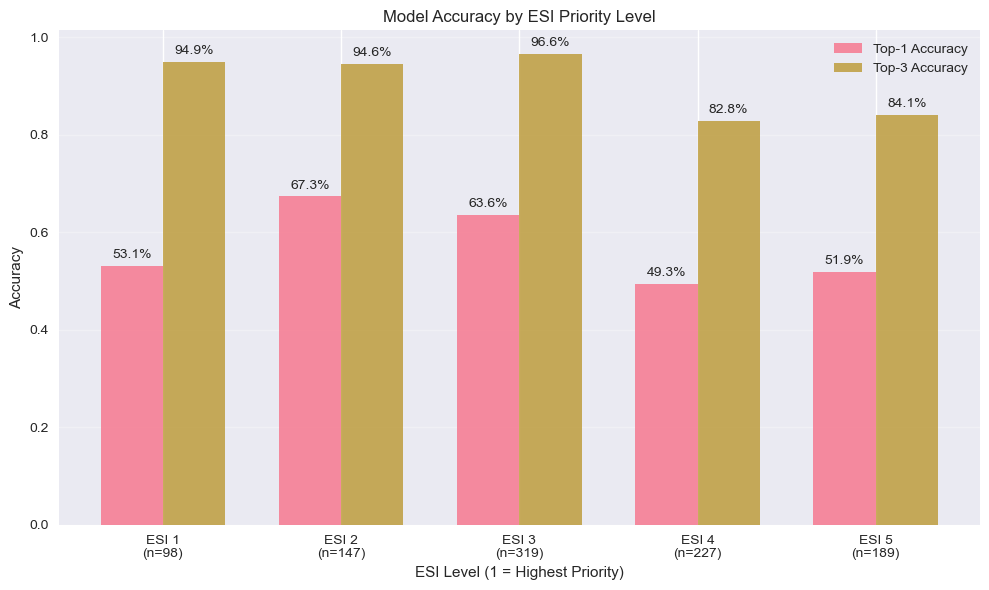

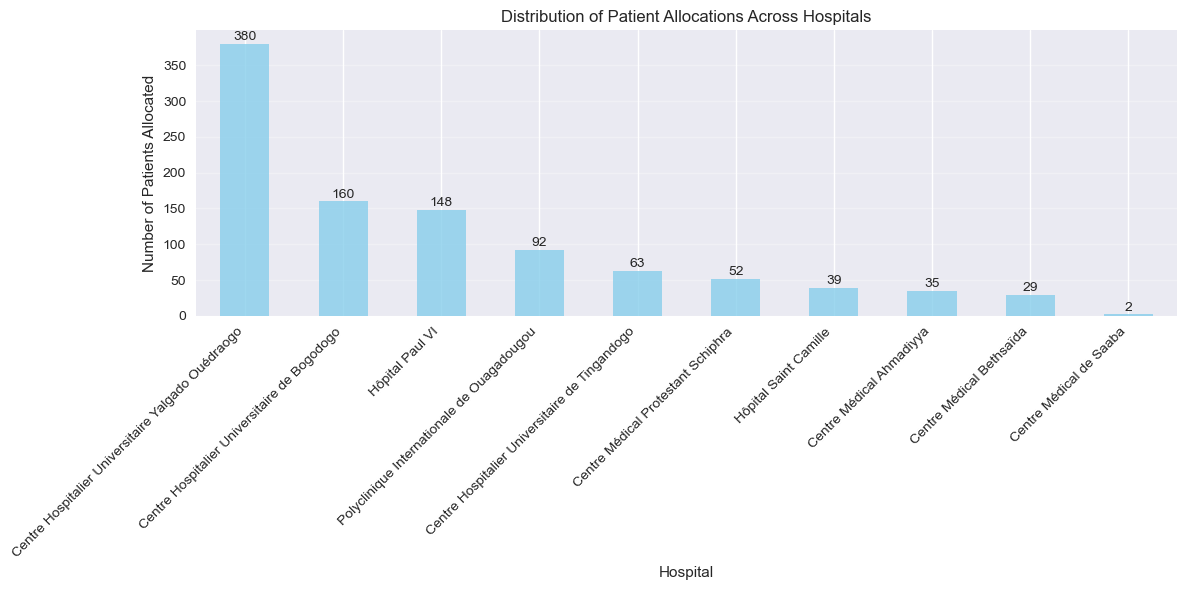

Performance visualizations completed!


In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# 1. Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
ax1.plot(epochs_range, history['val_loss'], label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history['val_acc'], label='Val Accuracy', color='green', marker='^')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# 3. Top-K Accuracy by ESI
esi_levels = [1, 2, 3, 4, 5]
top1_acc = []
top3_acc = []
sample_sizes = []

for esi in esi_levels:
    sub = test_patients[test_patients['ESI'] == esi]
    if len(sub) == 0:
        top1_acc.append(0)
        top3_acc.append(0)
        sample_sizes.append(0)
        continue
    top1, top3, tot = 0, 0, 0
    for _, p in sub.iterrows():
        if pd.isna(p['Hopital_Alloue']):
            continue
        true_h = p['Hopital_Alloue']
        recs = predict_hospital(p.to_dict(), hospitals)
        top_h = [r['hospital'] for r in recs[:3]]
        if true_h == recs[0]['hospital']:
            top1 += 1
        if true_h in top_h:
            top3 += 1
        tot += 1
    top1_acc.append(top1 / tot if tot > 0 else 0)
    top3_acc.append(top3 / tot if tot > 0 else 0)
    sample_sizes.append(tot)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(esi_levels))
width = 0.35

bars1 = ax.bar(x - width/2, top1_acc, width, label='Top-1 Accuracy', alpha=0.8)
bars2 = ax.bar(x + width/2, top3_acc, width, label='Top-3 Accuracy', alpha=0.8)

ax.set_xlabel('ESI Level (1 = Highest Priority)')
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy by ESI Priority Level')
ax.set_xticks(x)
ax.set_xticklabels([f'ESI {i}\n(n={s})' for i, s in zip(esi_levels, sample_sizes)])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.1%}', ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.1%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# 4. Hospital Allocation Distribution
plt.figure(figsize=(12, 6))
alloc_counts = patients['Hopital_Alloue'].value_counts()
alloc_counts.plot(kind='bar', color='skyblue', alpha=0.8)
plt.xlabel('Hospital')
plt.ylabel('Number of Patients Allocated')
plt.title('Distribution of Patient Allocations Across Hospitals')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(alloc_counts):
    plt.text(i, v + 1, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("Performance visualizations completed!")